# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Investigation of reducing selection strategies to top-k from experiment [2] \
[7] Investigation of reducing both selection strategies and num batches from experiment [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [1]:
# Some imports and general information

import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/perf_dal.db
# scp phahn@cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal.db .

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR10'}, 
    'stl10':{'qs':10, 'n':'STL10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red', 'ls':'-'},
    'badge':{'n':'BADGE', 'c':'blue', 'ls':'-'},
    'bait':{'n':'BAIT', 'c':'green', 'ls':'-'},
    'coreset':{'n':'CoreSet', 'c':'purple', 'ls':'-'},
    'dropquery':{'n':'DropQuery', 'c':'orange', 'ls':'-'},
    'margin':{'n':'Margin', 'c':'cyan', 'ls':'-'},
    'random':{'n':'Random', 'c':'black', 'ls':'-'},
    'typiclust':{'n':'Typiclust', 'c':'pink', 'ls':'-'},

    'lazy+vary oracle(11)':{'n':'Lazy+Var Oracle (11)', 'c':'red', 'ls':'--'},
    'lazy+vary oracle(55)':{'n':'Lazy+Var Oracle (55)', 'c':'red', 'ls':':'},
    'lazy+vary oracle(110)':{'n':'Lazy+Var Oracle (110)', 'c':'red', 'ls':'-.'},

    'lazy oracle(11)':{'n':'Lazy Oracle (11)', 'c':'red', 'ls':'--'},
    'lazy oracle(55)':{'n':'Lazy Oracle (55)', 'c':'red', 'ls':':'},
    'lazy oracle(110)':{'n':'Lazy Oracle (110)', 'c':'red', 'ls':'-.'},

    'naive oracle(11)':{'n':'Naive Oracle (11)', 'c':'blue', 'ls':'--'},
    'naive oracle(55)':{'n':'Naive Oracle (55)', 'c':'blue', 'ls':':'},
    'naive oracle(110)':{'n':'Naive Oracle (110)', 'c':'blue', 'ls':'-.'},

    'Lazy+Vary Oracle (acq_size = 5)':{'n':'acq_size = 5', 'c':'orange', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 10)':{'n':'acq_size = 10', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 20)':{'n':'acq_size = 20', 'c':'green', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 40)':{'n':'acq_size = 40', 'c':'red', 'ls':'--'},

    'Lazy+Vary Oracle (perf_est = cross_entropy)':{'n':'perf_est = cross_entropy', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = zero_one)':{'n':'perf_est = zero_one', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = brier)':{'n':'perf_est = brier', 'c':'green', 'ls':'--'},

    'Lazy+Vary Oracle (train = train)':{'n':'train = train', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (train = update)':{'n':'train = update', 'c':'blue', 'ls':'--'},

    'lazy+vary+red oracle(11)':{'n':'Lazy+Var+Red Oracle (11)', 'c':'orange', 'ls':'--'},
    'lazy+vary+red oracle(55)':{'n':'Lazy+Var+Red Oracle (55)', 'c':'orange', 'ls':':'},
    'lazy+vary+red oracle(110)':{'n':'Lazy+Var+Red Oracle (110)', 'c':'orange', 'ls':'-.'},

    'lazy+vary+red oracle(5)':{'n':'Lazy+Var+Red Oracle (5)', 'c':'gray', 'ls':'--'},
    'lazy+vary+red oracle(25)':{'n':'Lazy+Var+Red Oracle (25)', 'c':'gray', 'ls':':'},
    'lazy+vary+red oracle(50)':{'n':'Lazy+Var+Red Oracle (50)', 'c':'gray', 'ls':'-.'},

    'lazy+vary+red(1) oracle(110)':{'n':'Lazy+Var+Red(1) Oracle (110)', 'c':'silver', 'ls':'-.'},
    'lazy+vary+red(2) oracle(110)':{'n':'Lazy+Var+Red(2) Oracle (110)', 'c':'red', 'ls':'-.'},
    'lazy+vary+red(3) oracle(110)':{'n':'Lazy+Var+Red(3) Oracle (110)', 'c':'green', 'ls':'-.'},
    'lazy+vary+red(4) oracle(110)':{'n':'Lazy+Var+Red(4) Oracle (110)', 'c':'blue', 'ls':'-.'},
    'lazy+vary+red(5) oracle(110)':{'n':'Lazy+Var+Red(5) Oracle (110)', 'c':'gray', 'ls':'-.'},
    'lazy+vary+red(6) oracle(110)':{'n':'Lazy+Var+Red(6) Oracle (110)', 'c':'yellow', 'ls':'-.'},
    'lazy+vary+red(7) oracle(110)':{'n':'Lazy+Var+Red(7) Oracle (110)', 'c':'purple', 'ls':'-.'},
    'lazy+vary+red(8) oracle(110)':{'n':'Lazy+Var+Red(8) Oracle (110)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary+red(9) oracle(110)':{'n':'Lazy+Var+Red(9) Oracle (110)', 'c':'pink', 'ls':'-.'},
    'lazy+vary+red(10) oracle(110)':{'n':'Lazy+Var+Red(10) Oracle (110)', 'c':'brown', 'ls':'-.'},
    'lazy+vary+red(11) oracle(110)':{'n':'Lazy+Var+Red(11) Oracle (110)', 'c':'black', 'ls':'-.'},

    'lazy+vary oracle(110) cross_entropy 10':{'n':'Cross Entropy (10)', 'c':'green', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 10':{'n':'Zero One (10)', 'c':'green', 'ls':'-'},
    'lazy+vary oracle(110) cross_entropy 20':{'n':'Cross Entropy (20)', 'c':'blue', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 20':{'n':'Zero One (20)', 'c':'blue', 'ls':'-'},
    'lazy+vary oracle(110) cross_entropy 25':{'n':'Cross Entropy (25)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 25':{'n':'Zero One (25)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) cross_entropy 30':{'n':'Cross Entropy (30)', 'c':'red', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 30':{'n':'Zero One (30)', 'c':'red', 'ls':'-'},
    'lazy+vary oracle(110) cross_entropy 50':{'n':'Cross Entropy (50)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 50':{'n':'Zero One (50)', 'c':'cyan', 'ls':'-'},

    'Oracle':{'n':'Oracle', 'c':'black', 'ls':'-.'},

    "True - ['random', 'dropquery']":{}, 
    "False - ['random', 'dropquery']":{}, 
    "True - ['random', 'coreset']":{}, 
    "False - ['random', 'coreset']":{}, 
    "True - ['random', 'badge']":{}, 
    "False - ['random', 'badge']":{}, 
    "True - ['random', 'bait']":{}, 
    "False - ['random', 'bait']":{}, 
    "True - ['random', 'alfamix']":{}, 
    "False - ['random', 'alfamix']":{}, 
    "True - ['random', 'typiclust']":{}, 
    "False - ['random', 'typiclust']":{}, 
    "True - ['random', 'loss']":{}, 
    "False - ['random', 'loss']":{}, 
    "True - ['random', 'margin']":{}, 
    "False - ['random', 'margin']":{}, 
    "True - ['random', 'dropqueryclass']":{}, 
    "False - ['random', 'dropqueryclass']":{}
}

sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']
sampling_strategies_red =  ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'dropqueryclass']

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [2]:
experiment_name = 'experiment_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_1 #####################################
Found 720 experiments for experiment_1 with expected 720 experiments.


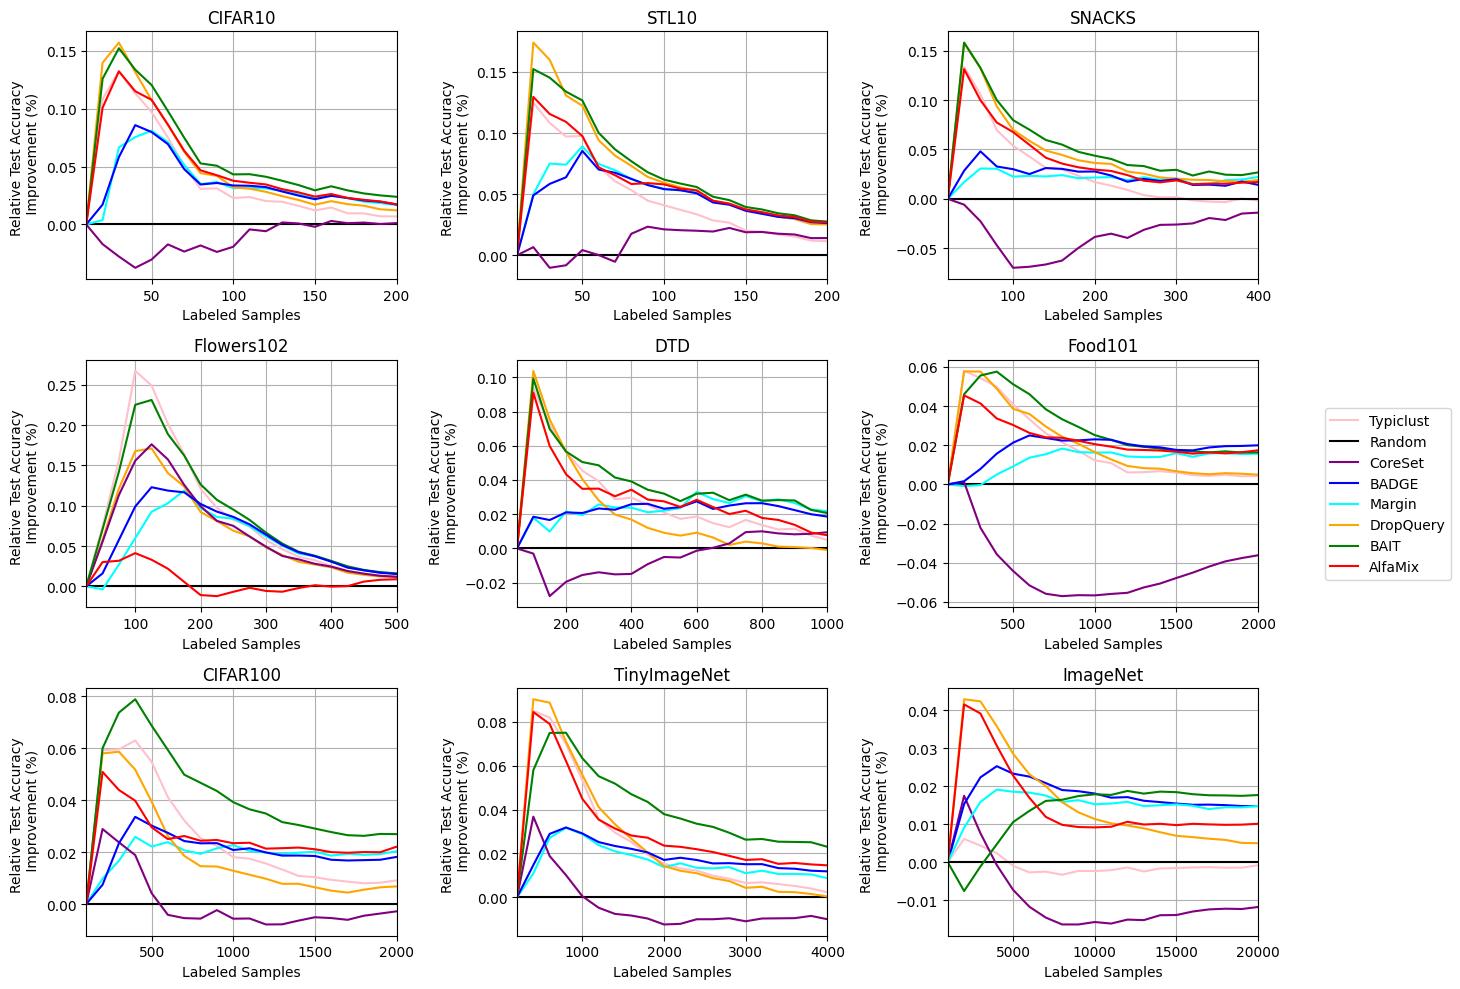

In [3]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)

for i, dset in enumerate(datasets):
    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

## Experiment 2 - Oracle Baselines

The second experiment investigates different variants of the oracle strategy and additionally tests them for different number of batches per cycle to investigate.

Oracle_Variants = [Naive, Lazy, Intelligent but Lazy]

Batch_Sizes = [11, 55, 110]

In [4]:
experiment_name = 'experiment_2'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3 * 3)) # n_dsets * n_seeds * n_oracles * n_batches

for run in runs_strategies:
    key = ('lazy' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + ('+vary ' if run.data.params['al.optimal.vary_strat_subset_size'] == 'True' else ' ') + 'oracle' + '('+ run.data.params['al.optimal.num_batches'] +')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_2 #####################################
Found 180 experiments for experiment_2 with expected 180 experiments.
Issue with naive oracle(110) dtd Seed_2


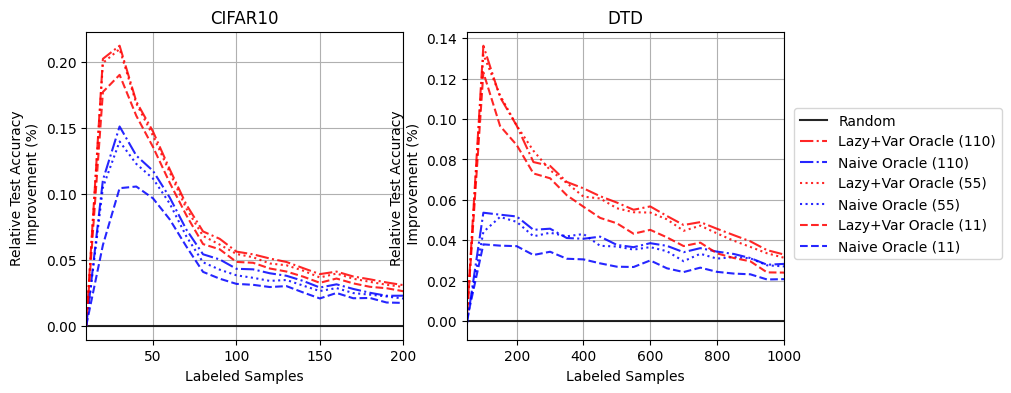

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if ('oracle' in qs and ('naive' in qs or 'lazy+vary' in qs)) or qs == 'random':
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.85, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.15, .5], handles=handles, labels=labels)
plt.savefig('./oracle_comparison.pdf', bbox_inches='tight')

In [9]:
# Table with AUC Values +/- STD

for ds in ['cifar10', 'dtd']:
    for strat in ['naive oracle', 'lazy+vary oracle']:
        for n_bat in ['11', '55', '110']:
            model = strat+'('+n_bat+')'
            accs = all_acc_curves_strategies[ds][model]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std = np.mean(aucs), np.std(aucs)
            print(ds, model, aucs_mean.round(4), aucs_std.round(4))

cifar10 naive oracle(11) 0.8707 0.0086
cifar10 naive oracle(55) 0.8801 0.0082
cifar10 naive oracle(110) 0.8845 0.0063
cifar10 lazy+vary oracle(11) 0.896 0.0075
cifar10 lazy+vary oracle(55) 0.9022 0.0068
cifar10 lazy+vary oracle(110) 0.9044 0.0072
dtd naive oracle(11) 0.6823 0.004
dtd naive oracle(55) 0.6906 0.0054
dtd naive oracle(110) 0.6925 0.0054
dtd lazy+vary oracle(11) 0.7051 0.0036
dtd lazy+vary oracle(55) 0.7133 0.0054
dtd lazy+vary oracle(110) 0.7148 0.0036


In [7]:
aucs

array([0.71499494, 0.71474164, 0.71952887, 0.71015704, 0.71995947,
       0.71451367, 0.71785714, 0.71562817, 0.70805471, 0.71296859])

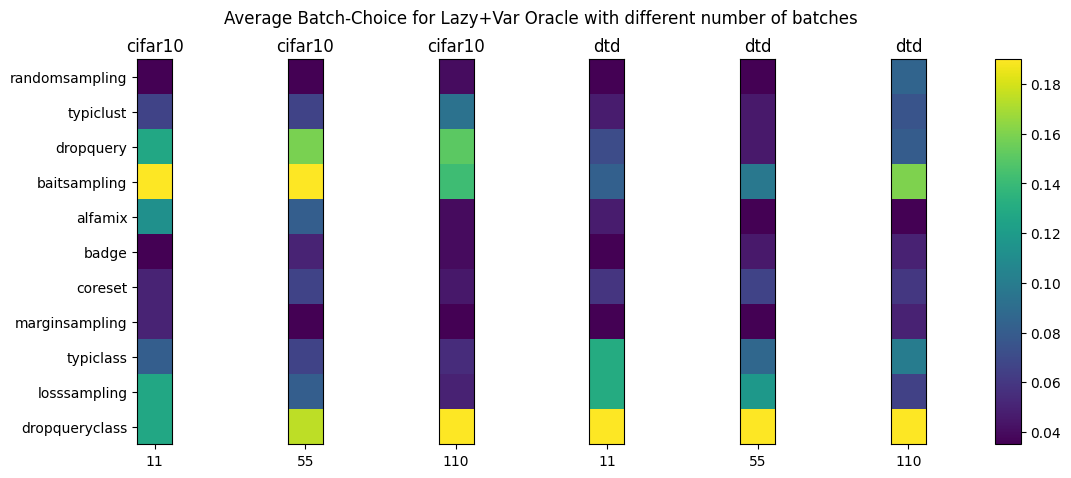

In [39]:
cmap = 'viridis'
fig_strats = ['lazy+vary oracle(11)', 'lazy+vary oracle(55)', 'lazy+vary oracle(110)',]
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(12, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Lazy+Var Oracle with different number of batches")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat.split('(')[1][:-1]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 3 - How does the query size impact the oracle?

This experiment demonstrates the change in performance when increasing the acq_size while keeping the total number of acquisitions over the experiment constant. 

We only use the strategy lazy+vary oracle(110) as it is the strongest performer.

Num_Acqs = [10, 20, 40]

Datasets = [CIFAR10, STL10]

In [14]:
experiment_name = 'experiment_3'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 4)) # n_dsets * n_seeds * n_acq_sizes

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (acq_size = '+run.data.params['al.acq_size']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_3 #####################################
Found 80 experiments for experiment_3 with expected 80 experiments.


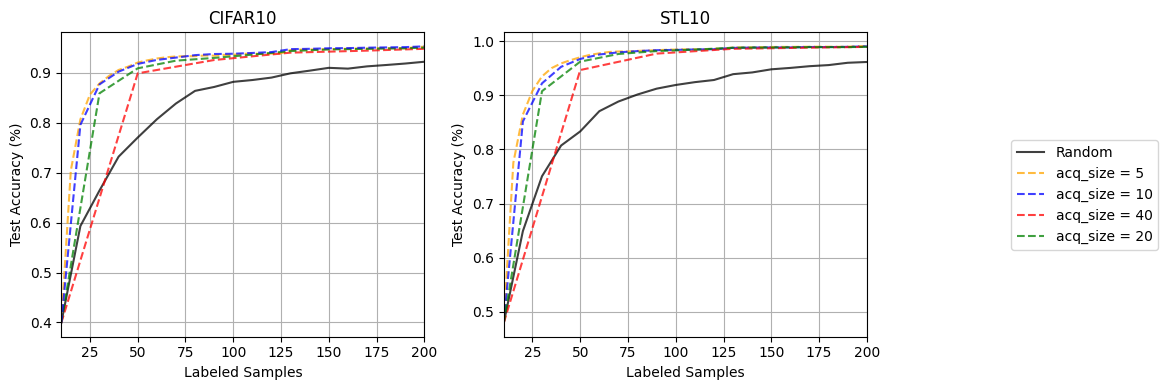

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'stl10']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'acq_size' in qs or qs == 'random':
            step_size = 1 if '5' in qs else (2 if ('10' in qs or qs == 'random') else (4 if '20' in qs else 8))
            n_labeled_samples = [j*5 + 10 for j in range(0, 41, step_size)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.3, .5], handles=handles, labels=labels)
plt.show()

#TODO: Better representation

In [16]:
# Create Table of AUC ranking

import pandas as pd

# Initialize a list to collect rows for the DataFrame
data_for_df = []

# Loop over datasets and strategies to calculate average AUC per strategy
for dataset, strategies in all_acc_curves_strategies.items():
    if dataset in ['stl10']:
        for strategy, accuracies in strategies.items():
            if 'acq_size' in strategy:
                # Flatten the list of lists (accuracies across cycles) and calculate the average AUC
                all_accuracies = np.array([[acc for acc in cycle] for cycle in accuracies])
                avg_auc = np.mean(all_accuracies)
                final_acc = np.mean(all_accuracies[:,-1])
                
                # Append the results to the data list
                data_for_df.append({'Dataset': dataset, 'Strategy': strategy, 'Average AUC': avg_auc, 'Final ACC': final_acc})

# Create a pandas DataFrame
df = pd.DataFrame(data_for_df)

# Sort the DataFrame by 'Average AUC' in descending order
df_sorted = df.sort_values(by='Average AUC', ascending=False)

# Display the result
df_sorted

,Dataset,Strategy,Average AUC,Final ACC
0,stl10,Lazy+Vary Oracle (acq_size = 5),0.960453,0.990900
1,stl10,Lazy+Vary Oracle (acq_size = 10),0.950165,0.990750
3,stl10,Lazy+Vary Oracle (acq_size = 20),0.930789,0.990363
2,stl10,Lazy+Vary Oracle (acq_size = 40),0.894706,0.990200


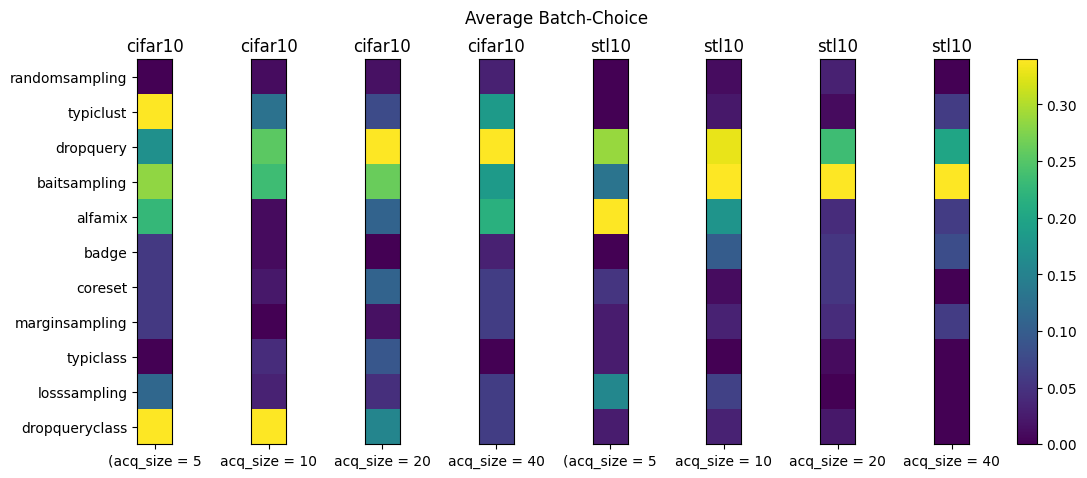

In [17]:
cmap = 'viridis'
fig_strats = ['Lazy+Vary Oracle (acq_size = 5)', 'Lazy+Vary Oracle (acq_size = 10)', 'Lazy+Vary Oracle (acq_size = 20)', 'Lazy+Vary Oracle (acq_size = 40)']
fig_dsets = ['cifar10', 'stl10']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(12, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat[-14:-1]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 4 - How does the performance estimation impact the oracle?

In this experiment, we investigate the influence of the performance metric used for evaluating the different batches.

Perf_Est = [Cross Entropy, 0/1 Loss, Brier Score]

In [18]:
experiment_name = 'experiment_4'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_loss_fn

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (perf_est = '+run.data.params['al.optimal.loss']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_4 #####################################
Found 60 experiments for experiment_4 with expected 60 experiments.


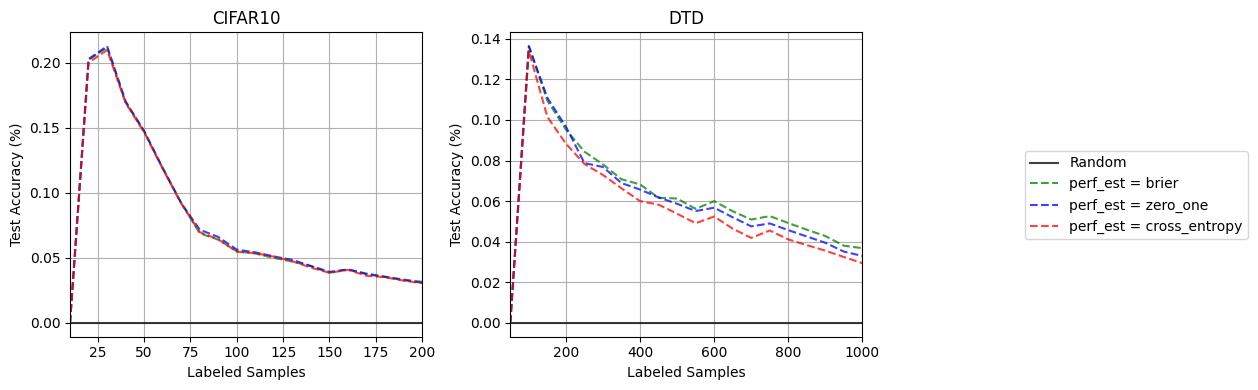

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'perf_est' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.4, .5], handles=handles, labels=labels)
plt.show()

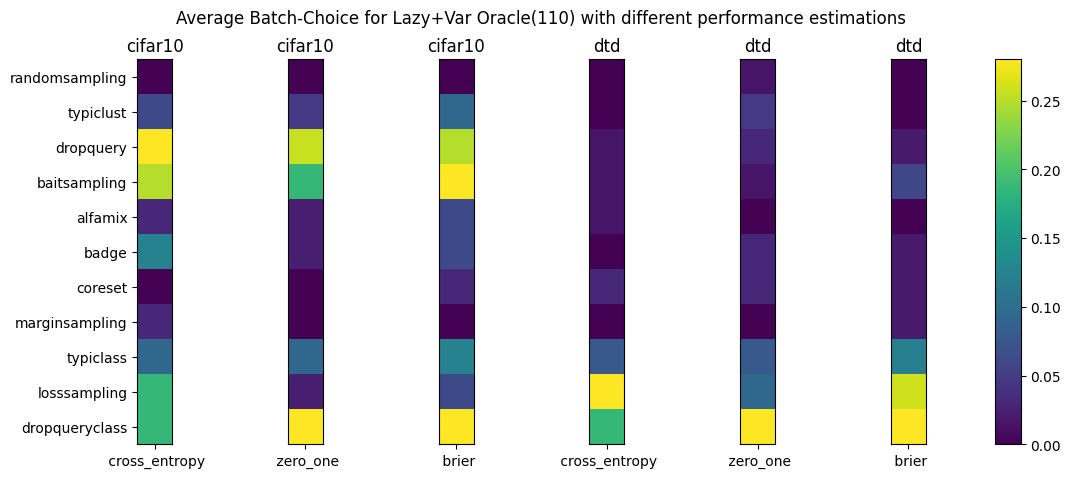

In [20]:
cmap = 'viridis'
fig_strats = ['Lazy+Vary Oracle (perf_est = cross_entropy)', 'Lazy+Vary Oracle (perf_est = zero_one)', 'Lazy+Vary Oracle (perf_est = brier)']
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(12, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Lazy+Var Oracle(110) with different performance estimations")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat.split('=')[1][:-1]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 5 - How does the retraining process impact the oracle?

This experiment investigates wether using bayesian updates instead of retraining the model from scratch can serve as a good performance estimator, making the oracle more efficient.

In [21]:
experiment_name = 'experiment_5'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 2)) # n_dsets * n_seeds * n_retrain_methods

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (train = '+run.data.params['al.optimal.retraining']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_5 #####################################
Found 40 experiments for experiment_5 with expected 40 experiments.


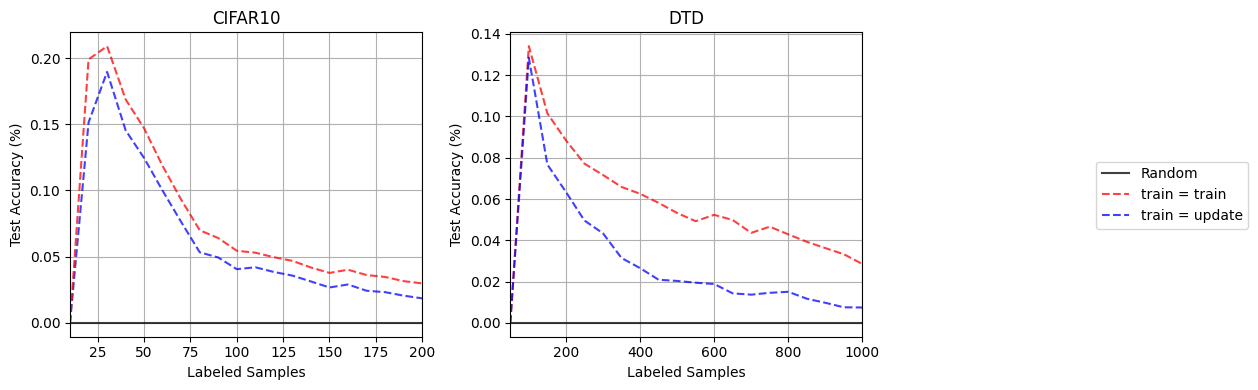

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'train' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.4, .5], handles=handles, labels=labels)
plt.show()

# TODO: Redo with Cross Entropy/Zero One, update_gamma=10, 20, 25, 30, 50

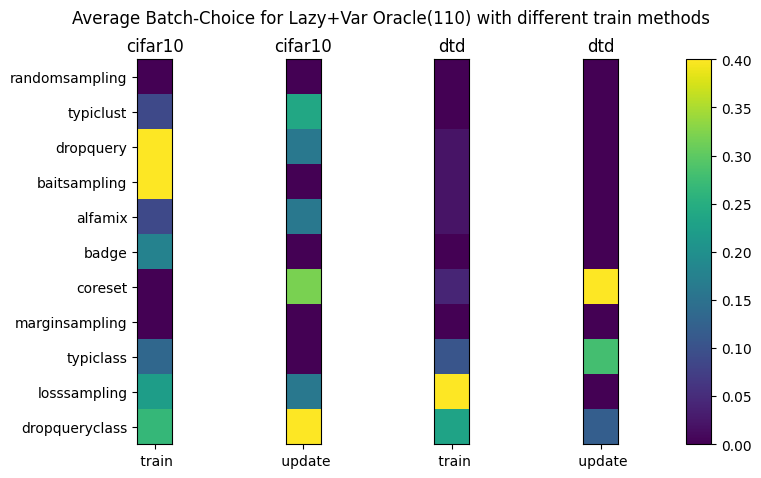

In [40]:
cmap = 'viridis'
fig_strats = ['Lazy+Vary Oracle (train = train)', 'Lazy+Vary Oracle (train = update)']
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(8, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Lazy+Var Oracle(110) with different train methods")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat.split('=')[1][:-1]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 6 - Is reducing the selection strategies to the most picked ones beneficial for the oracle?

This experiment investigates wether reducing the number of selection strategies to the most often used increases performance.

The strategies used were [Random, Typiclust, DropQuery, BAIT, DropQueryClass]

In [24]:
experiment_name = 'experiment_6'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_batches

for run in runs_strategies:
    n_bat = run.data.params['al.optimal.num_batches']
    key = f'lazy+vary+red oracle({n_bat})'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_6 #####################################
Found 60 experiments for experiment_6 with expected 60 experiments.


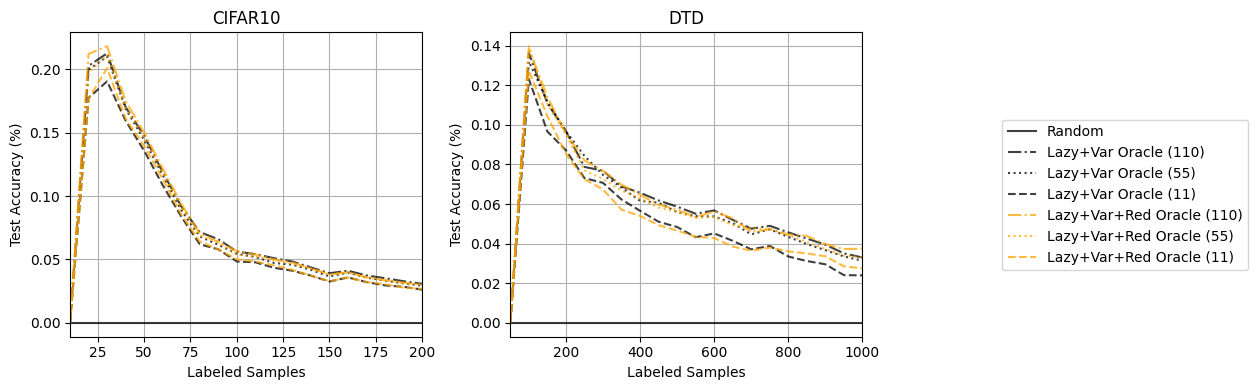

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'lazy+var' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.4, .5], handles=handles, labels=labels)
plt.show()

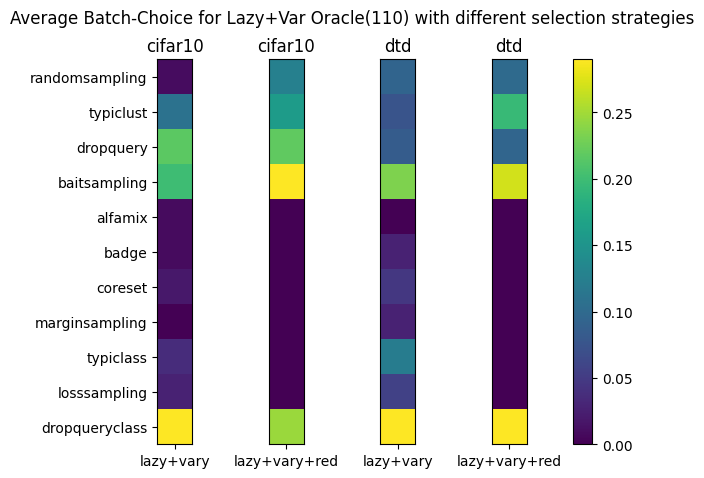

In [41]:
cmap = 'viridis'
fig_strats = ['lazy+vary oracle(110)', 'lazy+vary+red oracle(110)']
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(6, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Lazy+Var Oracle(110) with different selection strategies")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                if 'red' in strat and sampl_strat not in sampling_strategies_red:
                    im = [0 for _ in range(n_queries)]
                else:
                    im = []
                    if seed < len(all_pick_choices[dset][strat]):
                        for i in range(n_queries):
                            if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                                if i == 0:
                                    im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                                else:
                                    im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                            else:
                                im.append(0)
                img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat.split(' ')[0]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 7 - Is reducing the selection strategies to the most picked ones beneficial for the oracle even if we keep the num batches per strategy constant?

This is similar to exp. 6 with the difference, that we reduce the number of batches to lower amounts in order to see, if it can be more efficient.

Selection Strategies = Random, TypiClust, DropQuery, BAIT, DropClass

Num Batches = 5, 25, 50

In [27]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_batches

for run in runs_strategies:
    n_bat = run.data.params['al.optimal.num_batches']
    key = f'lazy+vary+red oracle({n_bat})'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_7 #####################################
Found 60 experiments for experiment_7 with expected 60 experiments.


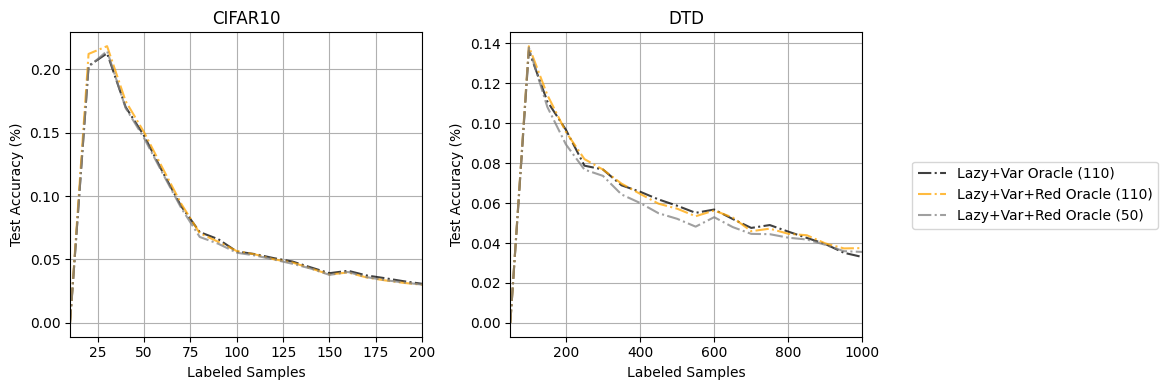

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'lazy+var' in qs or qs == 'random':
            if '110' in qs or '50' in qs:
                n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
                plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.3, .5], handles=handles, labels=labels)
plt.show()

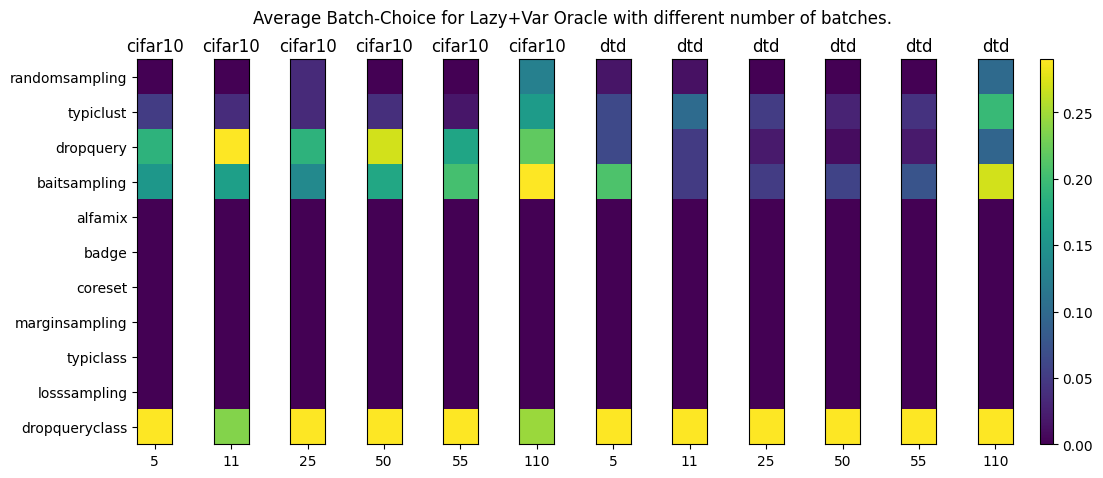

In [29]:
cmap = 'viridis'
fig_strats = [f'lazy+vary+red oracle({n_bat})' for n_bat in [5, 11, 25, 50, 55, 110]]
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(12, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Lazy+Var Oracle with different number of batches.")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                if 'red' in strat and sampl_strat not in sampling_strategies_red:
                    im = [0 for _ in range(n_queries)]
                else:
                    im = []
                    if seed < len(all_pick_choices[dset][strat]):
                        for i in range(n_queries):
                            if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                                if i == 0:
                                    im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                                else:
                                    im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                            else:
                                im.append(0)
                img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat.split('(')[1][:-1]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 8 - Is the addition of another sampling strategy always beneficial or can it hurt the performance by giving current sampling strategies less tries to find the best batch?

We start with Random and continually increase the different sampling strategies contained in the following order

[1] BAIT \
[2] DropQueryClass \
[3] DropQuery \
[4] TypiClust \
[5] TypiClass \
[6] Alfamix \
[7] CoreSet \
[8] BADGE \
[9] Margin \
[10] Loss 

The order is chosen based on results from experiment 2. Sadly, due to combinatorical explosion, we cannot test each combination.

In [30]:
experiment_name = 'experiment_8'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 8)) # n_dsets * n_seeds * n_sel_strat_combs

for run in runs_strategies:
    sel_strats = run.data.params['al.optimal.strategies']
    n_sel_strats = sel_strats.count(',')+1

    key = f'lazy+vary+red({n_sel_strats}) oracle(110)'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

# Reframe old experiment strategies in our notation
for dset in ['cifar10', 'dtd']:
    all_acc_curves_strategies[dset]['lazy+vary+red(1) oracle(110)'] = all_acc_curves_strategies[dset]['naive oracle(110)']
    all_acc_curves_strategies[dset]['lazy+vary+red(5) oracle(110)'] = all_acc_curves_strategies[dset]['lazy+vary+red oracle(110)']
    all_acc_curves_strategies[dset]['lazy+vary+red(11) oracle(110)'] = all_acc_curves_strategies[dset]['lazy+vary oracle(110)']

##################################### experiment_8 #####################################
Found 160 experiments for experiment_8 with expected 160 experiments.


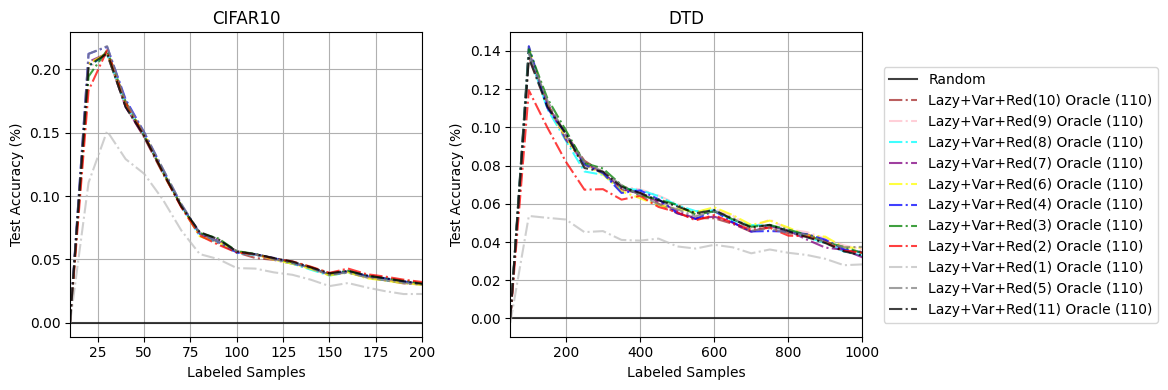

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'red(' in qs or qs == 'random':
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.3, .5], handles=handles, labels=labels)
plt.show()

In [32]:
# Create Table of AUC ranking

import pandas as pd

# Initialize a list to collect rows for the DataFrame
data_for_df = []

# Loop over datasets and strategies to calculate average AUC per strategy
for dataset, strategies in all_acc_curves_strategies.items():
    if dataset in ['cifar10']:
        for strategy, accuracies in strategies.items():
            if 'red' in strategy and '110' in strategy and 'd(' in strategy:
                # Flatten the list of lists (accuracies across cycles) and calculate the average AUC
                all_accuracies = np.array([[acc for acc in cycle] for cycle in accuracies])
                avg_auc = np.mean(all_accuracies)
                final_acc = np.mean(all_accuracies[:,-1])
                
                # Append the results to the data list
                data_for_df.append({'Dataset': dataset, 'Strategy': strategy, 'Average AUC': avg_auc, 'Final ACC': final_acc})

# Create a pandas DataFrame
df = pd.DataFrame(data_for_df)

# Sort the DataFrame by 'Average AUC' in descending order
df_sorted = df.sort_values(by='Average AUC', ascending=False)

# Display the result
df_sorted

,Dataset,Strategy,Average AUC,Final ACC
5,cifar10,lazy+vary+red(4) oracle(110),0.905340,0.95288
9,cifar10,lazy+vary+red(5) oracle(110),0.905096,0.95309
6,cifar10,lazy+vary+red(3) oracle(110),0.904452,0.95385
10,cifar10,lazy+vary+red(11) oracle(110),0.904423,0.95331
1,cifar10,lazy+vary+red(9) oracle(110),0.904126,0.95256
3,cifar10,lazy+vary+red(7) oracle(110),0.904101,0.95300
7,cifar10,lazy+vary+red(2) oracle(110),0.903754,0.95401
4,cifar10,lazy+vary+red(6) oracle(110),0.903718,0.95221
2,cifar10,lazy+vary+red(8) oracle(110),0.903609,0.95253
0,cifar10,lazy+vary+red(10) oracle(110),0.903371,0.95333


In [33]:
experiment_name = 'experiment_9'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 5 * 2)) # n_dsets * n_seeds * n_gammas * n_loss_fn

for run in runs_strategies:
    loss_fn = run.data.params['al.optimal.loss']
    update_gamma = run.data.params['al.optimal.update_gamma']

    key = f'lazy+vary oracle(110) ' + loss_fn + ' ' + update_gamma
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_9 #####################################
Found 200 experiments for experiment_9 with expected 200 experiments.


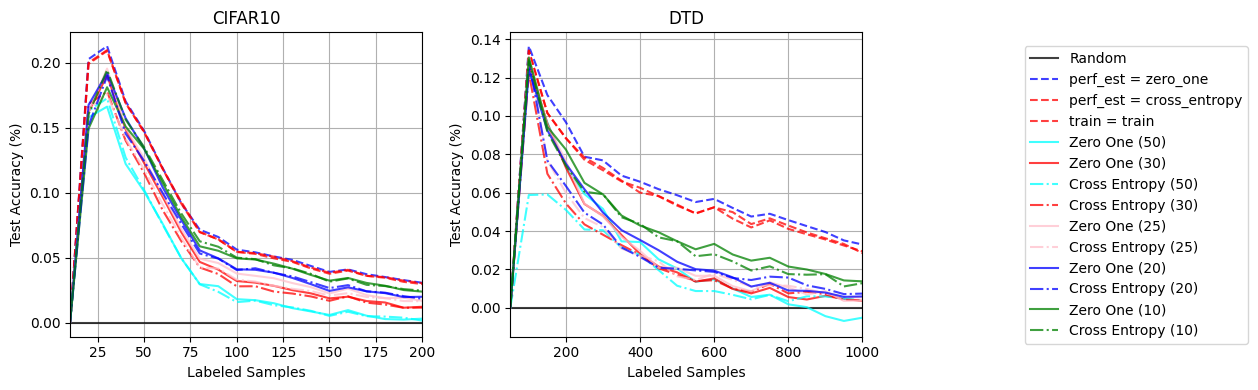

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.axes(ax[i])
    for qs in all_acc_curves_strategies[dset]:
        if 'train = train' in qs or qs == 'random' or 'cross_entropy' in qs or 'zero_one' in qs:
            n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0, 21, 1)]
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), alpha=.75, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.4, .5], handles=handles, labels=labels)
plt.show()

In [10]:
experiment_name = 'experiment_10'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_10 #####################################
Found 90 experiments for experiment_10 with expected 90 experiments.


In [11]:
for ds in ['cifar10', 'dtd']:
        model = 'Oracle'
        accs = all_acc_curves_strategies[ds][model]
        aucs = np.mean(accs, axis=1)
        aucs_mean, aucs_std = np.mean(aucs), np.std(aucs)
        print(ds, model, aucs_mean.round(4), aucs_std.round(4))

cifar10 Oracle 0.9038 0.0074
dtd Oracle 0.7165 0.0057


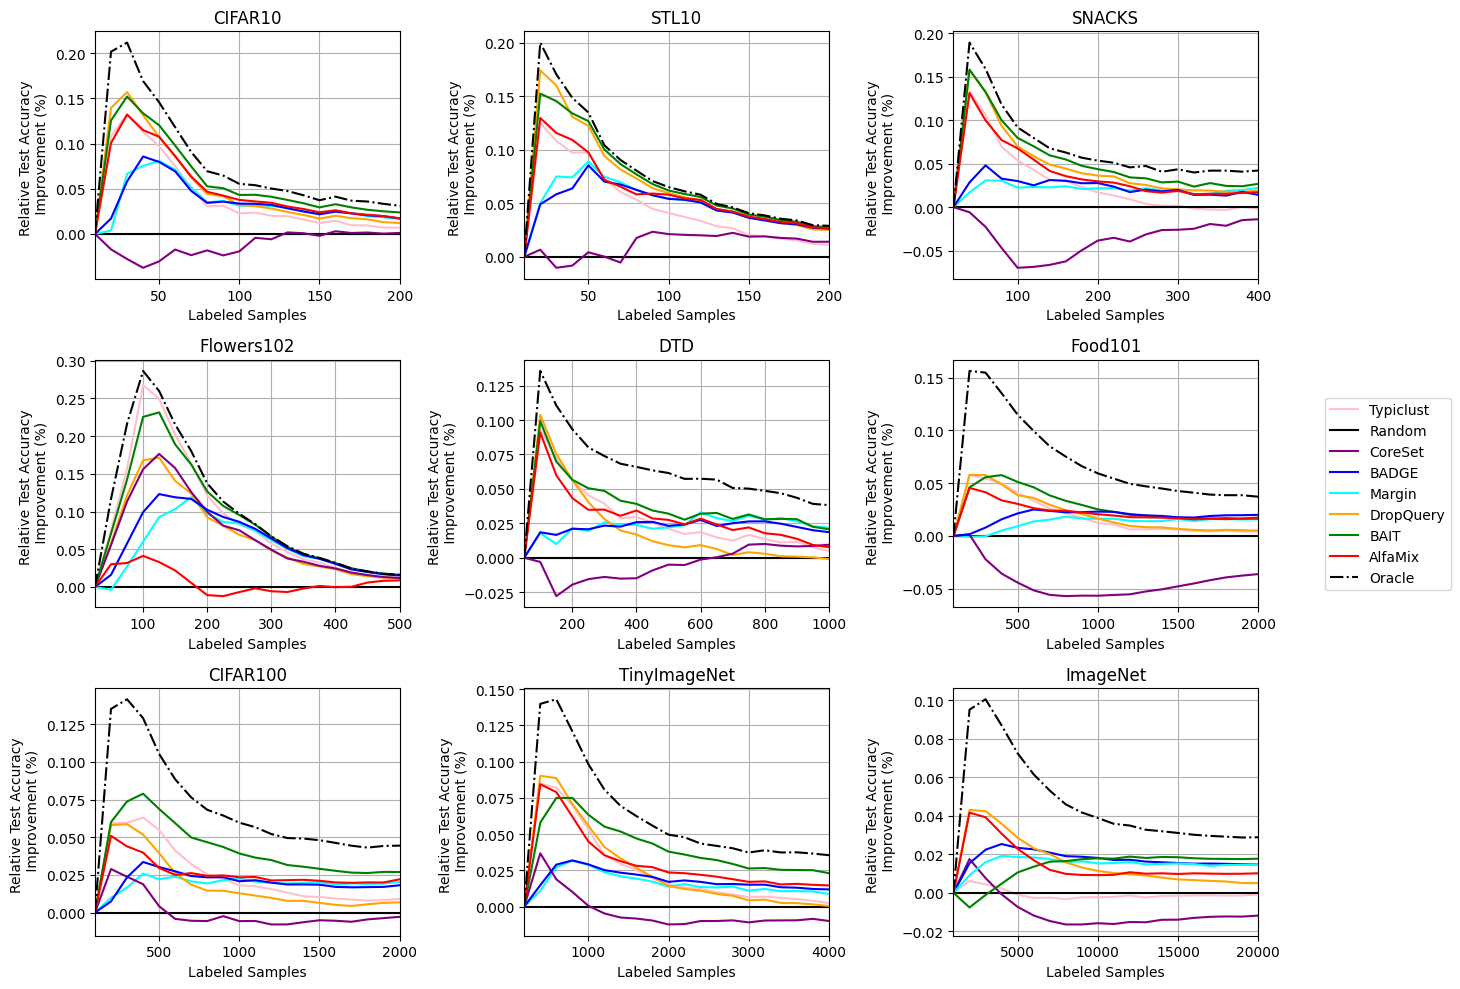

In [36]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)

for i, dset in enumerate(datasets):
    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if qs in ['random', 'margin', 'coreset', 'bait', 'badge', 'typiclust', 'alfamix', 'dropquery', 'Oracle']:
            plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

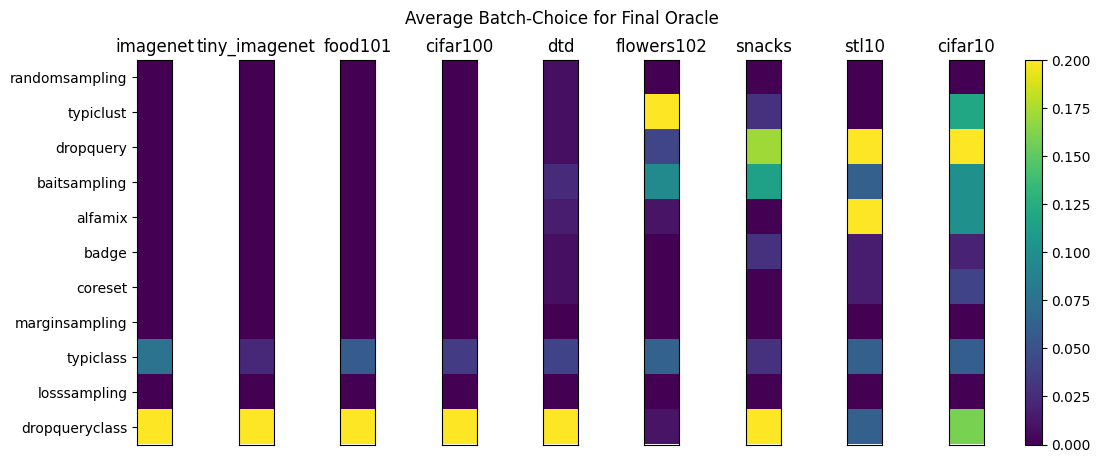

In [46]:
cmap = 'viridis'
fig_strats = ['Oracle']
fig_dsets = all_acc_curves_strategies.keys()
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(12, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Final Oracle")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                if 'red' in strat and sampl_strat not in sampling_strategies_red:
                    im = [0 for _ in range(n_queries)]
                else:
                    im = []
                    if seed < len(all_pick_choices[dset][strat]):
                        for i in range(n_queries):
                            if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                                if i == 0:
                                    im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                                else:
                                    im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                            else:
                                im.append(0)
                img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[], labels=[])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

In [3]:
experiment_name = 'experiment_11'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 2 * 9 * 10)) # n_dsets * n_var_types * n_strat_combs * n_seeds

for run in runs_strategies:
    key = run.data.params['al.optimal.vary_strat_subset_size'] + " - " + run.data.params['al.optimal.strategies']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_11 #####################################
Found 360 experiments for experiment_11 with expected 360 experiments.


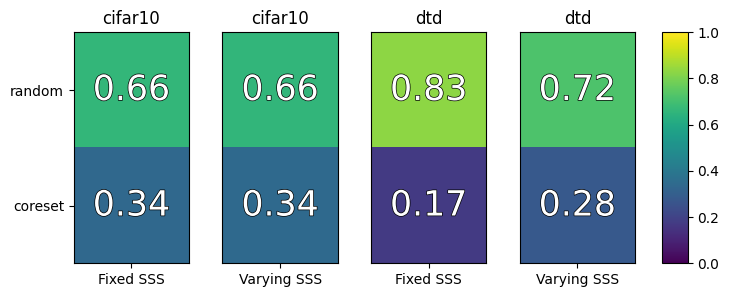

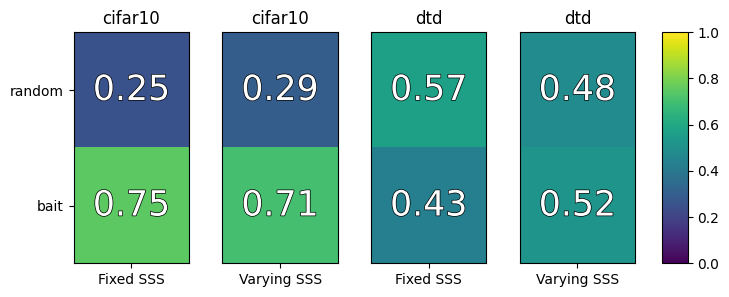

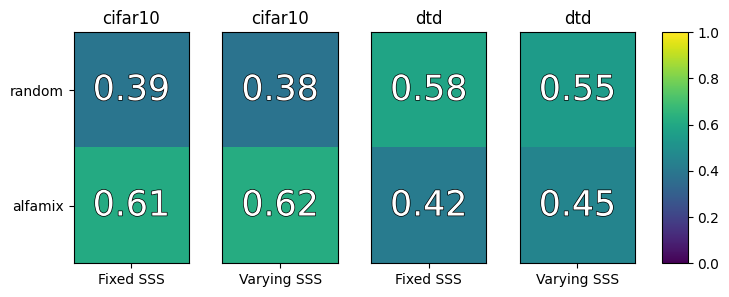

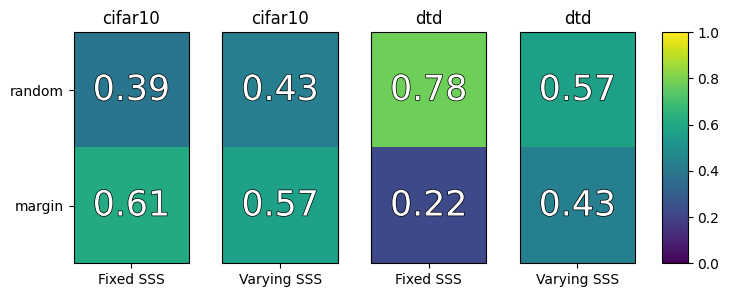

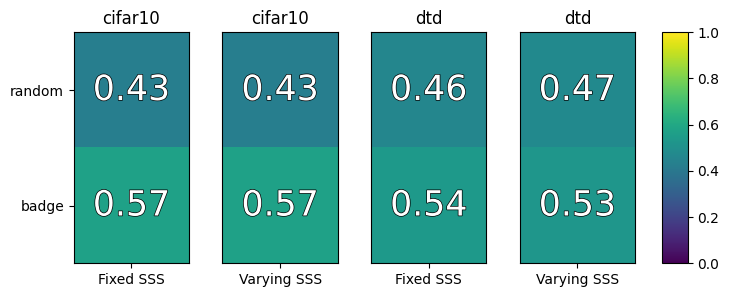

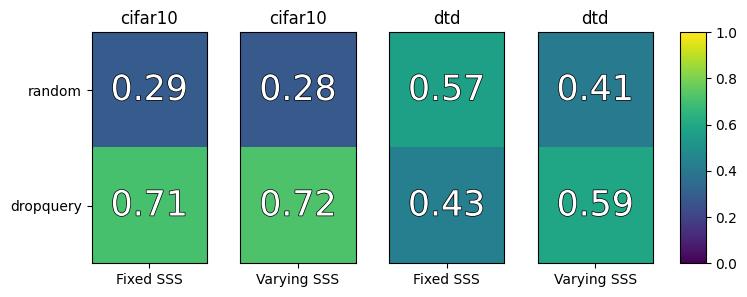

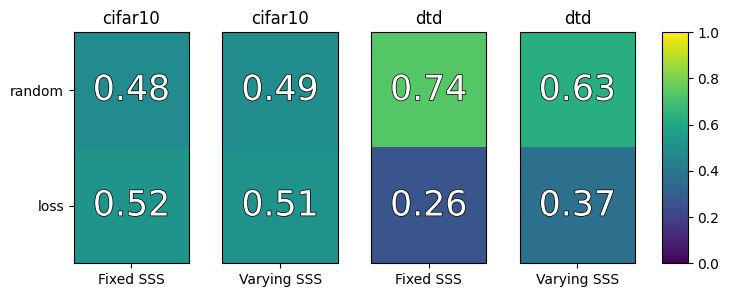

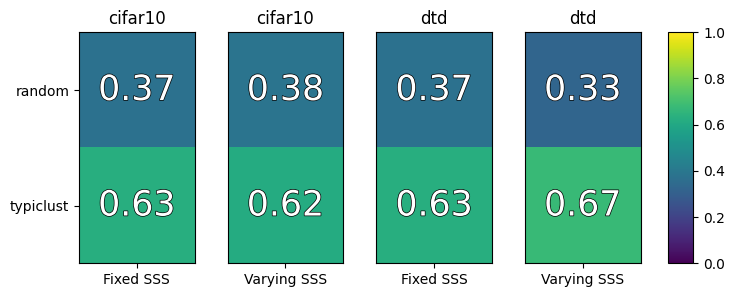

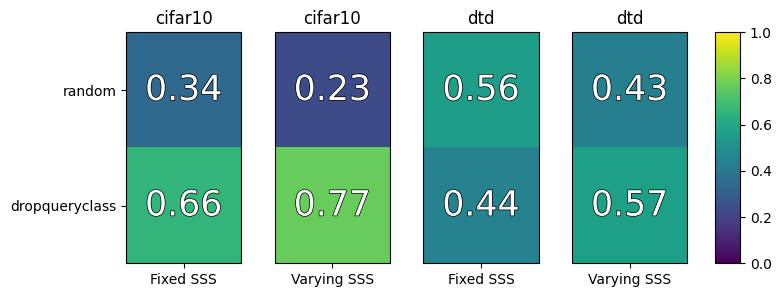

In [4]:
import matplotlib.patheffects as PathEffects
cmap = 'viridis'
fig_strats = [key for key in all_pick_choices['cifar10'].keys() if ' - ' in key]
fig_dsets = ['cifar10', 'dtd']
n_seeds = 10

for strat_b in list(set([fs.split(' - ')[1] for fs in fig_strats])):
    fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(8, 3), width_ratios=[1 for _ in range(4)]+ [.2])
    for b, dset in enumerate(fig_dsets):
        for a, strat_a in enumerate(['False', 'True']):
    
            strat = strat_a + ' - ' + strat_b
            n_queries = 20
        
            query_size = datasets[dset]['qs']
            
            j = a + b * 2
            vmin, vmax = 1, 0
            
            image = []
            sampl_strategies = ['random'] + [strat.split(',')[1][2:-2]]
            for sampl_strat in sampl_strategies:
                if sampl_strat == 'bait':
                    sampl_strat = 'baitsampling'
                if sampl_strat == 'margin':
                    sampl_strat = 'marginsampling'
                if sampl_strat == 'loss':
                    sampl_strat = 'losssampling'
                if sampl_strat == 'random':
                    sampl_strat = 'randomsampling'
                img = []
                for seed in range(n_seeds):
                    im = []
                    if seed < len(all_pick_choices[dset][strat]):
                        for i in range(1, n_queries):
                            if len(all_pick_choices[dset][strat][seed][sampl_strat]) > 0:
                                if i == 0:
                                    im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                                else:
                                    im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                            else:
                                im.append(0)
                    img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            vmin, vmax = 0, 1

            c1 = ax[j].imshow(img_avg, vmin=vmin, vmax=vmax)
            ax[j].set_xticks(ticks=[0], labels=['Varying SSS' if strat.split(' - ')[0] == 'True' else 'Fixed SSS'])
            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampl_strategies)), labels=sampl_strategies)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(dset)

            for i in range(2):
                text = ax[j].text(0, i, "{:.2f}".format(img_avg[i].item()), size=25, ha="center", va="center", color="w")
                text.set_path_effects([PathEffects.Stroke(linewidth=1, foreground='black'), PathEffects.Normal()])

            j += 1

    fig.colorbar(c1, cax=ax[-1])
    plt.show()